<a href="https://colab.research.google.com/github/rajesh-koduri/Fraud-detection/blob/main/basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
data = pd.read_csv("financial_transactions.csv")

In [13]:
data.head()

,transaction_amount,transaction_time,transaction_day,transaction_type,num_prev_transactions,avg_transaction_amount,account_age_days,is_foreign_transaction,time_since_last_transaction,day_of_week,fraud
0,93.85,14,23,transfer,6,180.16,1232,0,22.02,4,1
1,602.02,11,6,withdrawal,6,54.74,3148,0,19.70,1,0
2,263.35,15,3,transfer,5,190.48,823,0,13.97,3,0
3,182.59,23,22,transfer,4,49.19,881,0,41.24,6,0
4,33.92,18,11,transfer,4,144.33,2951,0,159.35,6,0


In [14]:
data.count()

,0
transaction_amount,1000
transaction_time,1000
transaction_day,1000
transaction_type,1000
num_prev_transactions,1000
avg_transaction_amount,1000
account_age_days,1000
is_foreign_transaction,1000
time_since_last_transaction,1000
day_of_week,1000


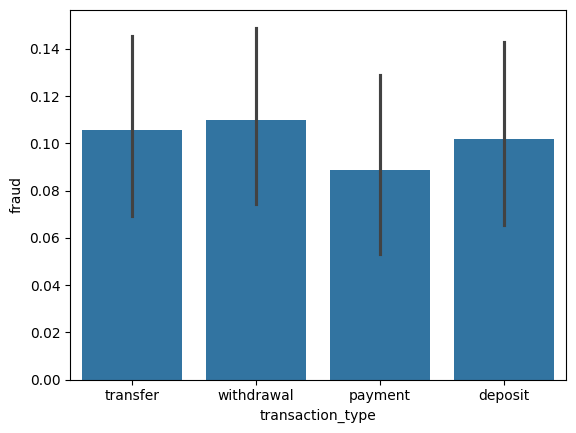

In [15]:
catagory_info =sns.barplot(data=data,x= "transaction_type",y = "fraud")

In [16]:
count_catagory = data['transaction_type'].value_counts()
print(count_catagory)

transaction_type
transfer      275
withdrawal    255
deposit       245
payment       225
Name: count, dtype: int64


In [17]:
result = data.groupby('transaction_type')['fraud'].value_counts().reset_index(name='count')
print(result)
d = pd.DataFrame(result)

  transaction_type  fraud  count
0          deposit      0    220
1          deposit      1     25
2          payment      0    205
3          payment      1     20
4         transfer      0    246
5         transfer      1     29
6       withdrawal      0    227
7       withdrawal      1     28


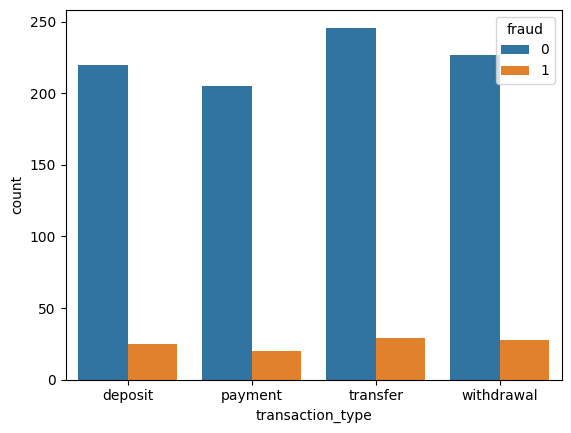

In [18]:
result1 = sns.barplot(data= d, x= "transaction_type",y ="count", hue='fraud' )

## Machine Learning Model for Fraud Prediction

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid modifying the original DataFrame
df_model = data.copy()

# Encode categorical features with separate LabelEncoders
le_transaction_type = LabelEncoder()
df_model['transaction_type_encoded'] = le_transaction_type.fit_transform(df_model['transaction_type'])

le_day_of_week = LabelEncoder()
df_model['day_of_week_encoded'] = le_day_of_week.fit_transform(df_model['day_of_week'])

# Define features (X) and target (y)
X = df_model.drop(['transaction_type', 'day_of_week', 'fraud'], axis=1)
y = df_model['fraud']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Data preprocessing complete. Training and testing sets created.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Data preprocessing complete. Training and testing sets created.
X_train shape: (700, 10), y_train shape: (700,)
X_test shape: (300, 10), y_test shape: (300,)


### Train the RandomForestClassifier Model

In [27]:
# Initialize and train the RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Use class_weight for imbalanced data
model.fit(X_train, y_train)

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


### Evaluate Model Performance

In [28]:
# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class (fraud)

# Evaluate the model
print("Confusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=['Actual Non-Fraud', 'Actual Fraud'], columns=['Predicted Non-Fraud', 'Predicted Fraud']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

Confusion Matrix:


,Predicted Non-Fraud,Predicted Fraud
Actual Non-Fraud,269,0
Actual Fraud,31,0



Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       269
           1       0.00      0.00      0.00        31

    accuracy                           0.90       300
   macro avg       0.45      0.50      0.47       300
weighted avg       0.80      0.90      0.85       300


ROC AUC Score: 0.4567


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Addressing Class Imbalance with SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

print(f"Original training set shape (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Original target distribution in training set:\n{y_train.value_counts()}")

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print(f"\nResampled training set shape (X_resampled, y_resampled): {X_resampled.shape}, {y_resampled.shape}")
print(f"Resampled target distribution in training set:\n{y_resampled.value_counts()}")

### Retrain Model with Resampled Data

In [ ]:
model_resampled = RandomForestClassifier(n_estimators=100, random_state=42) # Removed class_weight as SMOTE handles balance
model_resampled.fit(X_resampled, y_resampled)

print("RandomForestClassifier model retrained successfully with SMOTE resampled data.")

### Re-evaluate Model Performance (with SMOTE)

In [ ]:
# Make predictions on the original test set
y_pred_resampled = model_resampled.predict(X_test)
y_pred_proba_resampled = model_resampled.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Confusion Matrix (after SMOTE):")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_resampled), index=['Actual Non-Fraud', 'Actual Fraud'], columns=['Predicted Non-Fraud', 'Predicted Fraud']))

print("\nClassification Report (after SMOTE):")
print(classification_report(y_test, y_pred_resampled))

print(f"\nROC AUC Score (after SMOTE): {roc_auc_score(y_test, y_pred_proba_resampled):.4f}")

### Predict New Transactions (with SMOTE-trained model)

Let's re-run the prediction for a new transaction using the model trained with SMOTE.

In [ ]:
# Re-using the previously defined new_transaction_df
# Ensure column order matches training data
new_transaction_df = new_transaction_df[X_train.columns]

# Predict if the new transaction is fraud using the resampled model
new_prediction_resampled = model_resampled.predict(new_transaction_df)
new_prediction_proba_resampled = model_resampled.predict_proba(new_transaction_df)[:, 1]

print(f"Prediction for new transaction (after SMOTE): {'Fraud' if new_prediction_resampled[0] == 1 else 'Not Fraud'}")
print(f"Probability of fraud (after SMOTE): {new_prediction_proba_resampled[0]:.4f}")

### Predict New Transactions

Here's an example of how you would use the trained model to predict if a new, unseen transaction is fraudulent. You would need to create a pandas DataFrame for the new transaction with the same features as your training data, ensuring categorical features are encoded similarly.

In [29]:
# Example of a new transaction (replace with actual new transaction data)
# Make sure the columns match X_train after encoding
new_transaction_data = {
    'transaction_amount': [150.00],
    'transaction_time': [10],
    'transaction_day': [5],
    'num_prev_transactions': [7],
    'avg_transaction_amount': [160.00],
    'account_age_days': [1500],
    'is_foreign_transaction': [0],
    'time_since_last_transaction': [25.0],
    'transaction_type_encoded': [le_transaction_type.transform(['transfer'])[0]], # Use the correct encoder
    'day_of_week_encoded': [le_day_of_week.transform([3])[0]] # Use the correct encoder for day_of_week
}

new_transaction_df = pd.DataFrame(new_transaction_data)

# Ensure column order matches training data
new_transaction_df = new_transaction_df[X_train.columns]

# Predict if the new transaction is fraud
new_prediction = model.predict(new_transaction_df)
new_prediction_proba = model.predict_proba(new_transaction_df)[:, 1]

print(f"Prediction for new transaction: {'Fraud' if new_prediction[0] == 1 else 'Not Fraud'}")
print(f"Probability of fraud: {new_prediction_proba[0]:.4f}")

Prediction for new transaction: Not Fraud
Probability of fraud: 0.2300


In [24]:
data.head()

,transaction_amount,transaction_time,transaction_day,transaction_type,num_prev_transactions,avg_transaction_amount,account_age_days,is_foreign_transaction,time_since_last_transaction,day_of_week,fraud
0,93.85,14,23,transfer,6,180.16,1232,0,22.02,4,1
1,602.02,11,6,withdrawal,6,54.74,3148,0,19.70,1,0
2,263.35,15,3,transfer,5,190.48,823,0,13.97,3,0
3,182.59,23,22,transfer,4,49.19,881,0,41.24,6,0
4,33.92,18,11,transfer,4,144.33,2951,0,159.35,6,0
